# CS 171 Group Project - Checkpoint 1

**Team 1:** Nathan Montero, Suparn Posina, and Arushi Nirmal

This notebook runs the complete USDA F-MAP regression checkpoint: dataset download, EDA, leakage-safe lag features, chronological split, mean baseline, Ridge, Decision Tree, Random Forest, MLP, LSTM, validation metrics, and figures.

Before running, choose **Runtime > Change runtime type > T4 GPU**. The 2018 test set remains reserved by default.

In [ ]:
import torch, platform
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("For the full LSTM run, switch Colab to a T4 GPU runtime.")

Python: 3.12.13
PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
from google.colab import files
from pathlib import Path
import os
import shutil
import zipfile

# Upload CS171_Checkpoint1_Complete_Package.zip when prompted.
uploaded = files.upload()

zip_files = [name for name in uploaded if name.lower().endswith(".zip")]
if not zip_files:
    raise FileNotFoundError("Upload CS171_Checkpoint1_Complete_Package.zip")

zip_path = Path("/content") / zip_files[0]
project_dir = Path("/content/cs171project")

shutil.rmtree(project_dir, ignore_errors=True)
project_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as archive:
    archive.extractall(project_dir)

os.chdir(project_dir)

print("Working directory:", Path.cwd())
print("requirements.txt exists:", Path("requirements.txt").exists())
print("checkpoint1.py exists:", Path("src/checkpoint1.py").exists())

Saving CS171_Checkpoint1_Complete_Package.zip to CS171_Checkpoint1_Complete_Package.zip
Working directory: /content/cs171project
requirements.txt exists: True
checkpoint1.py exists: True


In [ ]:
!python -m pip install -q --upgrade pip
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.2 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import pandas as pd

from src.checkpoint1 import (
    DATA_URL,
    TARGET,
    FEATURES,
    download_dataset,
    load_data,
    summarize_eda,
    save_eda_figures,
    engineer_features,
    chronological_split,
)

data_path = Path("data/fmap.xlsx")
figure_dir = Path("outputs/figures")
table_dir = Path("outputs/tables")

figure_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

# Load the USDA dataset.
download_dataset(DATA_URL, data_path)
raw = load_data(data_path)

print("Original dataset shape:", raw.shape)
display(raw.head())

In [ ]:
# EDA summary
eda_summary = summarize_eda(raw)
eda_table = pd.DataFrame(
    {
        "Statistic": list(eda_summary.keys()),
        "Value": list(eda_summary.values()),
    }
)

display(eda_table)

print("\nMissing values by column:")
display(
    raw.isna()
       .sum()
       .rename("Missing values")
       .to_frame()
       .sort_values("Missing values", ascending=False)
)

print("Duplicate Year-Month-Food-Area records:")
print(
    raw.duplicated(
        ["Year", "Month", "EFPG_code", "Metroregion_code"]
    ).sum()
)

raw[TARGET].describe()

In [ ]:
from IPython.display import Image, display

save_eda_figures(raw, figure_dir)

display(Image(filename="outputs/figures/target_distribution.png", width=700))
display(Image(filename="outputs/figures/monthly_average_trend.png", width=700))

In [ ]:
# Feature engineering
processed = engineer_features(raw)

print("Original shape:", raw.shape)
print("Processed shape:", processed.shape)

new_features = [
    "date",
    "month_sin",
    "month_cos",
    "price_lag_1",
    "price_lag_3",
    "price_lag_12",
    "price_roll_3",
    "price_roll_12",
]

display(
    processed[
        [
            "Year",
            "Month",
            "EFPG_name",
            "Metroregion_name",
            TARGET,
        ] + new_features
    ].head(10)
)

In [ ]:
split = chronological_split(processed)

split_table = pd.DataFrame(
    {
        "Split": ["Training", "Validation", "Reserved test"],
        "Years": ["2013–2016", "2017", "2018"],
        "Rows": [
            len(split.train),
            len(split.validation),
            len(split.test),
        ],
    }
)

display(split_table)

print("Features used by the models:")
for feature in FEATURES:
    print("-", feature)

## Run the complete checkpoint

This uses validation year 2017 and does **not** evaluate the reserved 2018 test year.

In [ ]:
!python src/checkpoint1.py --output-dir outputs --model-dir models

Downloaded 12.5 MB
{
  "rows": 113400,
  "columns": 15,
  "first_year": 2012,
  "last_year": 2018,
  "unique_months": 84,
  "food_groups": 90,
  "geographic_areas": 15,
  "missing_cells": 0,
  "duplicate_keys": 0,
  "target_mean": 0.5963235097001763,
  "target_median": 0.46,
  "target_standard_deviation": 0.44413155063898757,
  "target_minimum": 0.033,
  "target_maximum": 3.29,
  "target_skewness": 1.7857235009038737
}
LSTM device: cuda
LSTM epoch 01: train MSE=0.251506, validation MSE=0.016304
LSTM epoch 02: train MSE=0.025624, validation MSE=0.011922
LSTM epoch 03: train MSE=0.021383, validation MSE=0.010610
LSTM epoch 04: train MSE=0.019844, validation MSE=0.009982
LSTM epoch 05: train MSE=0.018187, validation MSE=0.009241
LSTM epoch 06: train MSE=0.016955, validation MSE=0.008390
LSTM epoch 07: train MSE=0.015886, validation MSE=0.007779
LSTM epoch 08: train MSE=0.015403, validation MSE=0.007499
LSTM epoch 09: train MSE=0.014771, validation MSE=0.007308
LSTM epoch 10: train MSE=0.0

In [ ]:
import pandas as pd
metrics = pd.read_csv("outputs/tables/validation_metrics.csv")
metrics

,Model,RMSE,MAE,R2
0,Random Forest,0.030130,0.016096,0.995693
1,LSTM,0.032216,0.017465,0.995076
2,MLP,0.033071,0.021836,0.994811
3,Ridge,0.033238,0.017416,0.994758
4,Decision Tree,0.033299,0.018285,0.994739
5,Mean baseline,0.459227,0.344415,-0.000579


outputs/figures/target_distribution.png


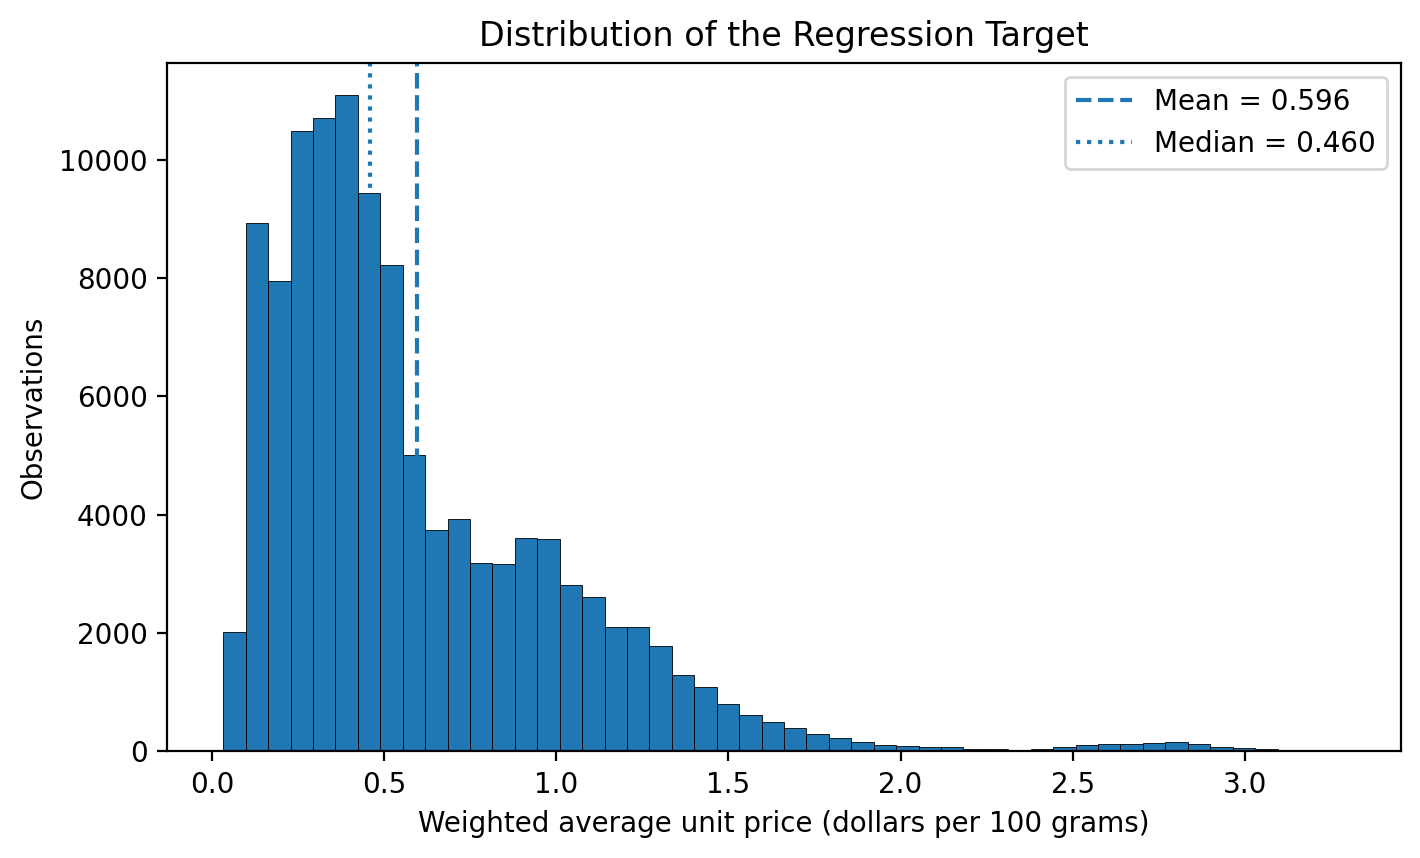

outputs/figures/monthly_average_trend.png


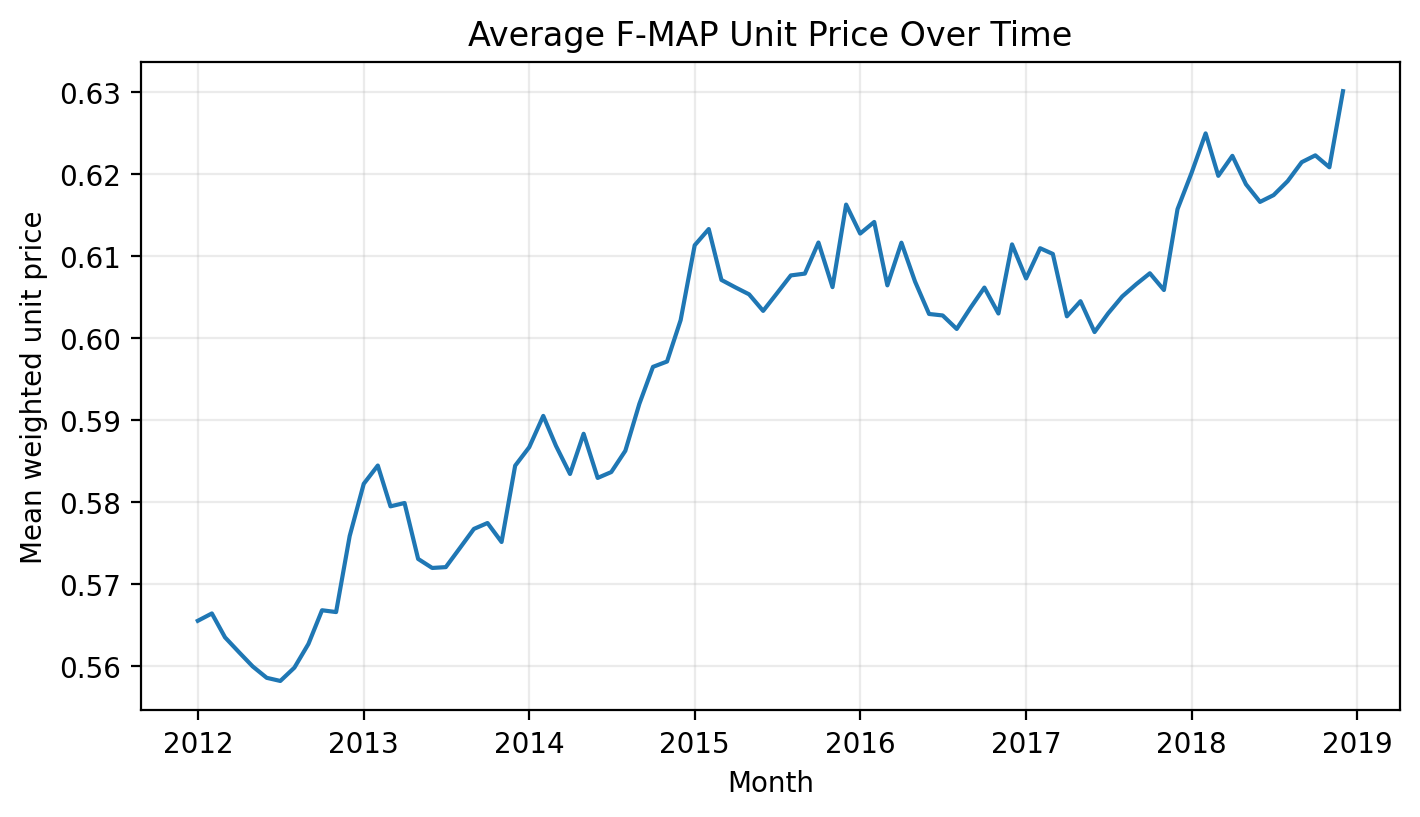

outputs/figures/model_comparison.png


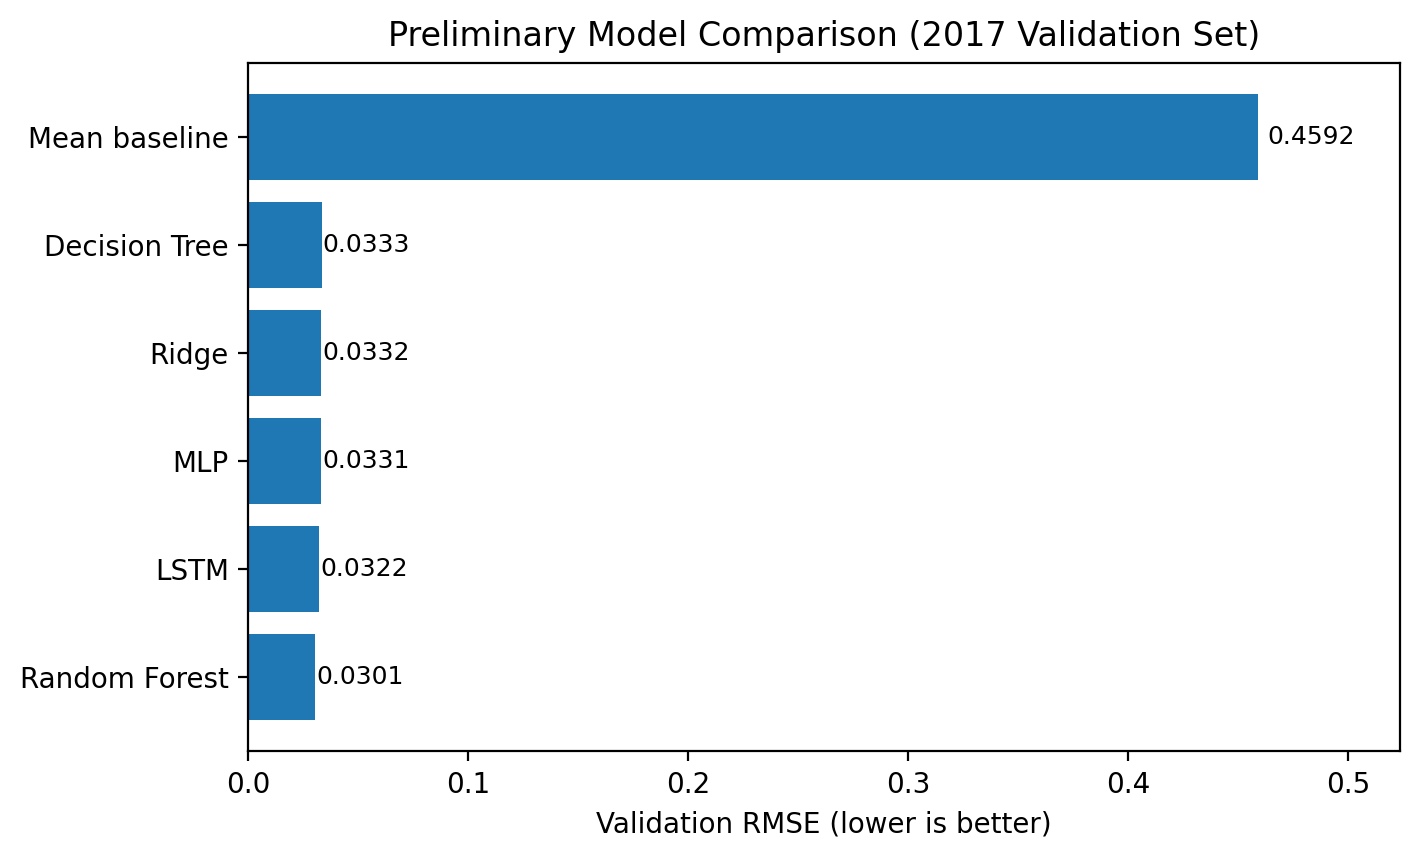

outputs/figures/rf_actual_vs_predicted.png


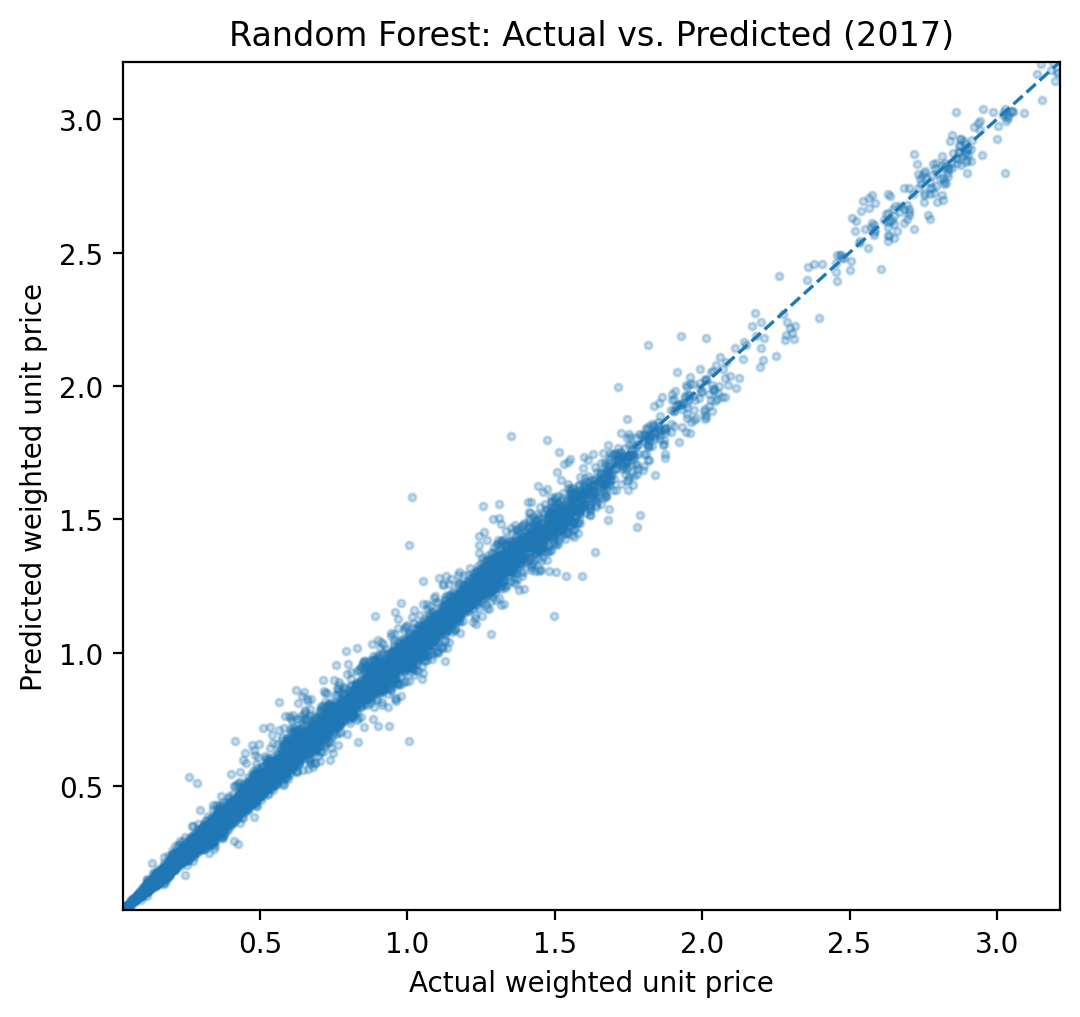

outputs/figures/rf_feature_importance.png


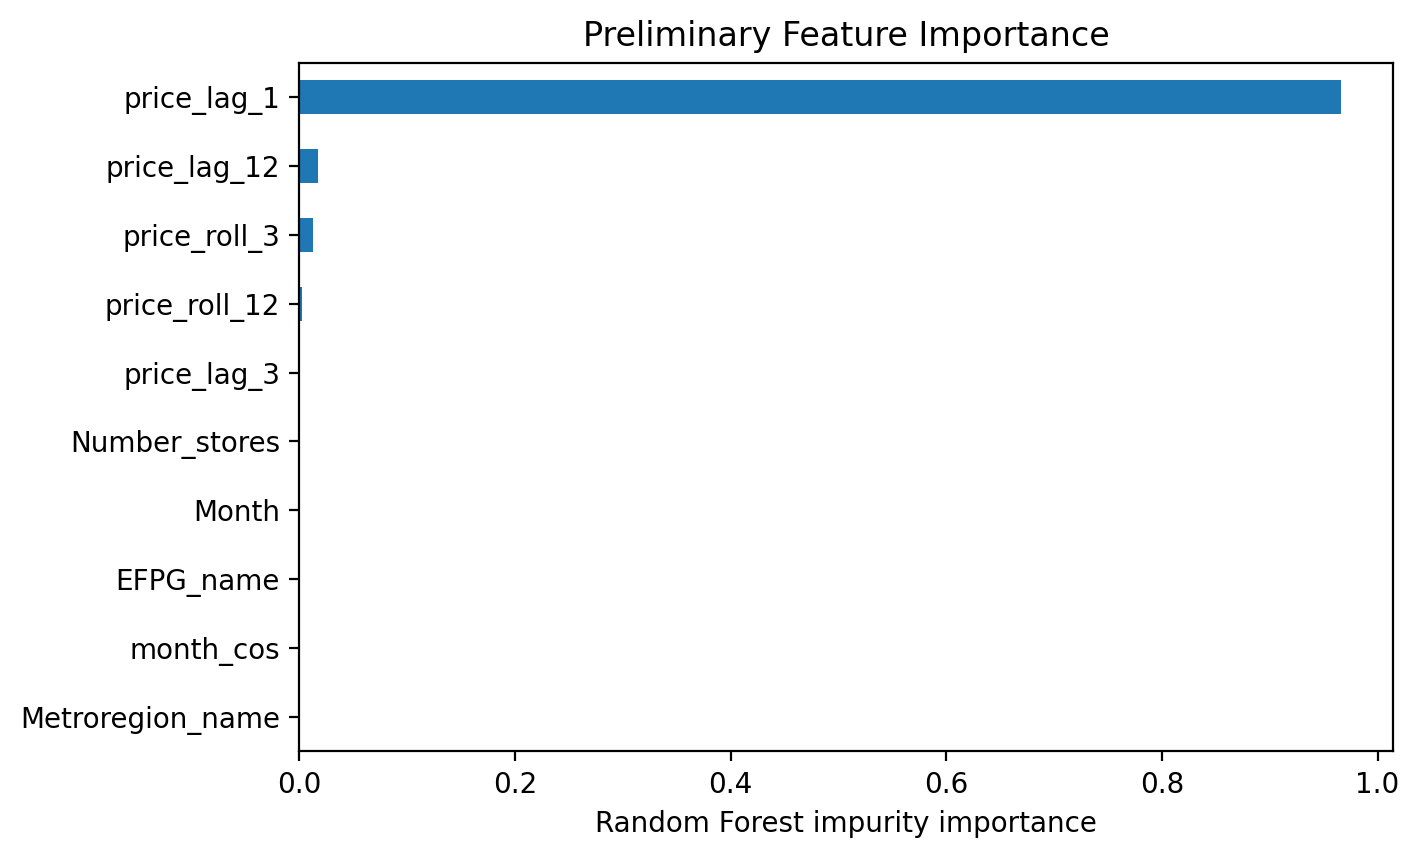

outputs/figures/rf_error_food_groups.png


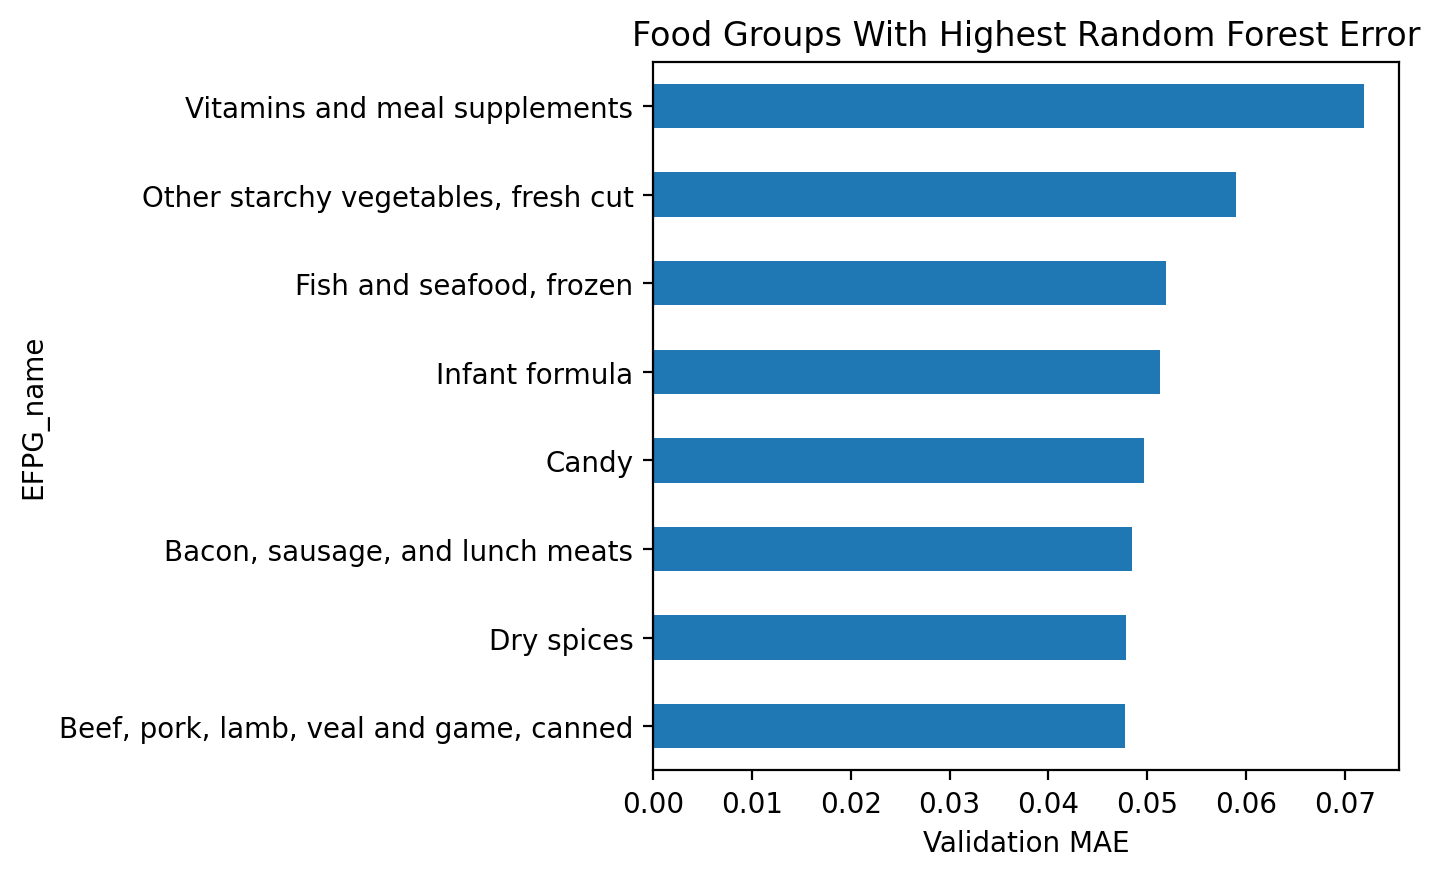

outputs/figures/mlp_training_curve.png


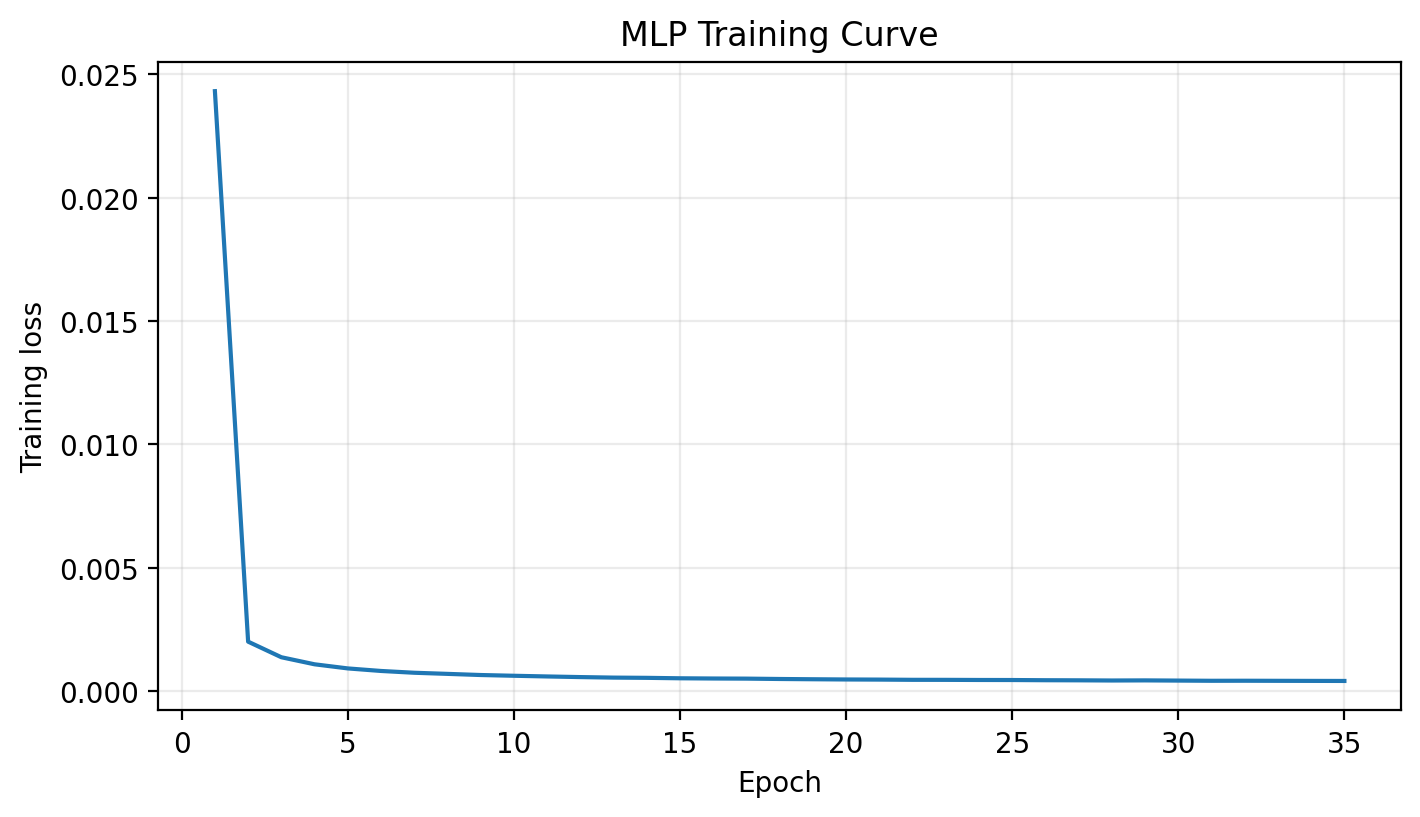

outputs/figures/lstm_training_curve.png


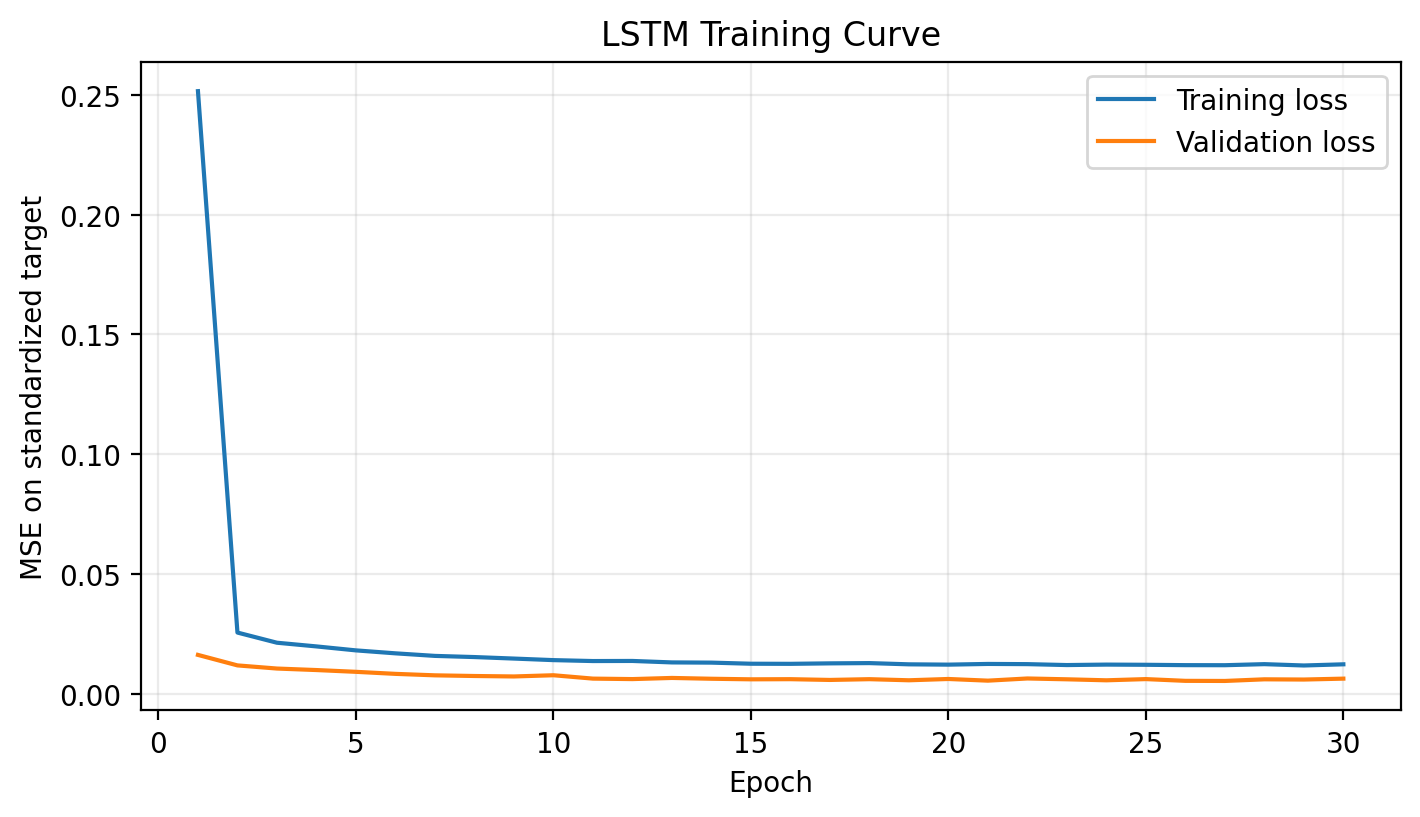

In [ ]:
from pathlib import Path
from IPython.display import Image, display

figure_paths = [
    "outputs/figures/target_distribution.png",
    "outputs/figures/monthly_average_trend.png",
    "outputs/figures/model_comparison.png",
    "outputs/figures/rf_actual_vs_predicted.png",
    "outputs/figures/rf_feature_importance.png",
    "outputs/figures/rf_error_food_groups.png",
    "outputs/figures/mlp_training_curve.png",
    "outputs/figures/lstm_training_curve.png",
]

for path in figure_paths:
    if Path(path).exists():
        print(path)
        display(Image(filename=path, width=750))

## Download generated outputs

The checkpoint PDF is already stored in `reports/`. The command below also packages the newly generated tables and figures.

In [ ]:
!zip -qr checkpoint1_generated_outputs.zip outputs
from google.colab import files
files.download("checkpoint1_generated_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Final-project-only test command

Do not run this until all modeling decisions are frozen:

```bash
python src/checkpoint1.py --evaluate-test
```

Continuing to tune after viewing the 2018 results would contaminate the held-out test set.